In [1]:
import sys
from pathlib import Path

# add the directory that contains `package/`
sys.path.insert(0, str(Path("..").resolve()))
sys.path

['/Users/selin/PycharmProjects/InsDelGLM',
 '/Users/selin/PycharmProjects/InsDelGLM',
 '/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev',
 '/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/jupyter_debug',
 '/Users/selin/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python311.zip',
 '/Users/selin/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11',
 '/Users/selin/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/lib-dynload',
 '',
 '/Users/selin/PycharmProjects/InsDelGLM/.venv/lib/python3.11/site-packages']

In [2]:
import torch
import pandas as pd
import numpy as np
import logomaker
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from collections import Counter
from helpers.seq_logo import DNALandscape
from helpers.conf_matrix import plot_evaluation_results

from modules.dna_tokenizer import DNATokenizer
from modules.custom_bert import DNABertForMaskedLM

In [3]:
# --- SETUP ---
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device: ", device)

# Load Tokenizer & Model

model_path = "../model/Betta_deletion_100k_1e-5"
#tokenizer = DNATokenizer.from_pretrained(model_path)
tokenizer = DNATokenizer(deletion_token=True)
model = DNABertForMaskedLM.from_pretrained(model_path)
model.to(device)
model.eval()


# Load Data
test_df = pd.read_parquet("../data/simulated/deletion_test.parquet")
print(f"Loaded {len(test_df)} test sequences.")

# Load Motifs
with open("../data/simulated/motifs.txt", "r") as f:
    motifs = [line.strip() for line in f.readlines()]
MOTIF_A = motifs[0]
MOTIF_B = motifs[1]
print(f"Ground Truth Motifs:\nMotif A: {MOTIF_A}\nMotif B: {MOTIF_B}")

Using device:  mps
Loaded 20000 test sequences.
Ground Truth Motifs:
Motif A: GCGA
Motif B: CCAGT


In [4]:
# --- DATA "BASELINES" (real baseline is Panther_baseline) ---
all_tokens = []
for seq in test_df["sequences"]:
    all_tokens.extend(list(seq))

counts = Counter(all_tokens)
total_tokens = sum(counts.values())

print("Token Distribution:")
for token, count in counts.items():
    print(f"{token}: {count / total_tokens:.2%}")

random_baseline = 1 / len(counts)
most_common_token, most_common_count = counts.most_common(1)[0]
majority_baseline = most_common_count / total_tokens

print(f"\n--- Baselines ---")
print(f"Random Guess (1/{len(counts)}): {random_baseline:.2%}")
print(f"Majority Class (Always predict '{most_common_token}'): {majority_baseline:.2%}")

Token Distribution:
T: 19.14%
A: 20.81%
G: 22.47%
C: 22.55%
-: 15.03%

--- Baselines ---
Random Guess (1/5): 20.00%
Majority Class (Always predict 'C'): 22.55%


In [5]:
def precompute_motif_metadata(df, motif_map):
    """
    Scans the dataset ONCE and saves start/end indices for all motifs.
    """
    df_meta = df.copy()

    print("Pre-computing motif positions...")
    for name, seq in motif_map.items():
        # Find start index (-1 if not found)
        df_meta[f'{name}_start'] = df_meta['sequences'].str.find(seq)

        # Calculate end index
        df_meta[f'{name}_end'] = df_meta.apply(
            lambda x: x[f'{name}_start'] + len(seq) if x[f'{name}_start'] != -1 else -1,
            axis=1
        )

    return df_meta


# --- EXECUTE ---
motif_map = {
    "Motif_A": MOTIF_A,
    "Motif_B": MOTIF_B
}

test_df_enriched = precompute_motif_metadata(test_df, motif_map)
print("Metadata computed. Sample:")
test_df_enriched[[col for col in test_df_enriched.columns if 'start' in col]].head()

Pre-computing motif positions...
Metadata computed. Sample:


,motif_A_start,motif_B_start,Motif_A_start,Motif_B_start
6383,9.0,21.0,9,21
13772,NaN,6.0,-1,6
69532,9.0,20.0,9,20
31213,12.0,NaN,-1,-1
9520,NaN,NaN,-1,-1


In [6]:
test_df_enriched

,sequences,labels,motif_A_start,motif_A_end,motif_B_start,motif_B_end,id,Motif_A_start,Motif_A_end,Motif_B_start,Motif_B_end
6383,TAATAAGAGGCGATACTT-A-CCAGTGCG-TAGG-,both,9.0,13.0,21.0,26.0,6383,9,13,21,26
13772,-GAACGCCAGTAG-AAGTG-GCACATCT-ACCTAT,B,NaN,NaN,6.0,11.0,13772,-1,-1,6,11
69532,GGCT---TTGCGAAG-ATCCCCAGTGGAAGCAA-G,both,9.0,13.0,20.0,25.0,69532,9,13,20,25
31213,CGCCGCTCACTCG-CG-AG-C-TG-TCC-ATGTTA,A,12.0,18.0,NaN,NaN,31213,-1,-1,-1,-1
9520,CTCGAGT-AT-GA-ATAACCTCACGGTCG-CTGAT,none,NaN,NaN,NaN,NaN,9520,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...
16537,CTCATT-TTAGCGAC--TCCAGCCAGTCCTATC--,both,10.0,14.0,22.0,27.0,16537,10,14,22,27
52506,T-TC-CATGCG-ACAAGGCCCAG-TCTACGGTCCT,both,8.0,13.0,19.0,25.0,52506,-1,-1,-1,-1
57634,CCTCCTCAA-GCGCC-AGTGGAGATC---TCAGCT,B,NaN,NaN,13.0,19.0,57634,-1,-1,-1,-1
40269,-GTA-ACCTCGCGATCAAGGCCAGTTT-AC-GAGA,both,10.0,14.0,20.0,25.0,40269,10,14,20,25


In [7]:
print("mask_token_id:", tokenizer.mask_token_id)
print("vocab_size:", model.config.vocab_size)

mask_token_id: 6
vocab_size: 9


In [8]:
def evaluate_and_collect_stats(model, tokenizer, test_sequences, batch_size=16):
    model.eval()

    # Storage for all masked instances
    all_preds = []
    all_labels = []

    class TestDataset(Dataset):
        def __init__(self, seqs): self.seqs = seqs
        def __len__(self): return len(self.seqs)
        def __getitem__(self, i): return self.seqs[i]

    dataloader = DataLoader(TestDataset(test_sequences), batch_size=batch_size)

    print("Running evaluation with stats collection...")
    with torch.no_grad():
        for batch_seqs in tqdm(dataloader):
            encoded = tokenizer(batch_seqs, return_tensors="pt", padding="max_length", max_length=512)
            input_ids = encoded["input_ids"].to(device)
            attention_mask = encoded["attention_mask"].to(device)
            labels = input_ids.clone()

            # --- MASKING STRATEGY ---
            # Note: Ensure (input_ids < 5) targets your nucleotides correctly.
            # In many tokenizers, IDs 0-4 are special tokens (CLS, SEP, etc.).
            rand = torch.rand(input_ids.shape).to(device)
            mask_indices = (rand < 0.15) & (input_ids < 5) & (attention_mask == 1)

            input_ids[mask_indices] = tokenizer.mask_token_id

            # Predict
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            predictions = torch.argmax(outputs.logits, dim=-1)

            # --- COLLECT DATA ---
            # We only care about the positions we actually masked
            if mask_indices.sum() > 0:
                masked_p = predictions[mask_indices].cpu().numpy()
                masked_l = labels[mask_indices].cpu().numpy()

                all_preds.extend(masked_p)
                all_labels.extend(masked_l)

    return np.array(all_labels), np.array(all_preds)

# --- EXECUTE COLLECTION ---
true_ids, pred_ids = evaluate_and_collect_stats(model, tokenizer, test_df["sequences"].tolist())

# Calculate Accuracy manually from the lists
acc = (true_ids == pred_ids).mean()
print(f"\nTest Set Masked Accuracy: {acc:.2%}")

Running evaluation with stats collection...


100%|██████████| 1250/1250 [01:15<00:00, 16.66it/s]


Test Set Masked Accuracy: 23.55%


/Users/selin/PycharmProjects/InsDelGLM/helpers/conf_matrix.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts_ordered, palette="viridis")


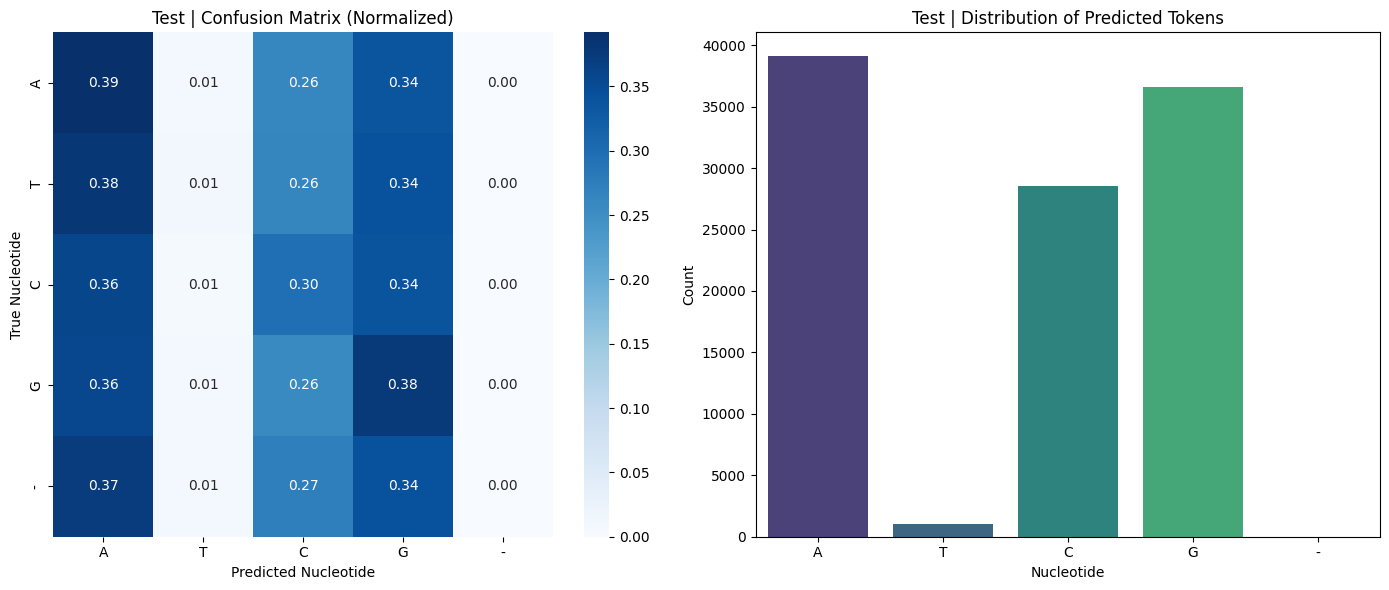

In [9]:
plot_evaluation_results(
    true_ids,
    pred_ids,
    tokenizer,
    dataset_name="Test"
)

In [10]:
# Initialize (Pass model once). For font, you can just use the default in the helper.
viz = DNALandscape(model, tokenizer, seq_len = 35, font="Arial Rounded MT Bold", use_ic=True)

# aggregated per position
#viz.plot_aggregated(test_df_enriched, "Motif_A", MOTIF_A)
viz.generate_aggregated_gif(test_df_enriched, "Motif_A", MOTIF_A, filename="Motif_A_del.gif", fps=2)
#viz.plot_aggregated(test_df_enriched, "Motif_B", MOTIF_B)
viz.generate_aggregated_gif(test_df_enriched, "Motif_B", MOTIF_B, filename="Motif_B_del.gif", fps=2)


--- Generating GIF for Motif_A (32 frames) ---
Rendering Frame: Start Index 0 (N=49)...
Rendering Frame: Start Index 1 (N=118)...
Rendering Frame: Start Index 2 (N=222)...
Rendering Frame: Start Index 3 (N=360)...
Rendering Frame: Start Index 4 (N=454)...
Rendering Frame: Start Index 5 (N=459)...
Rendering Frame: Start Index 6 (N=507)...
Rendering Frame: Start Index 7 (N=482)...
Rendering Frame: Start Index 8 (N=523)...
Rendering Frame: Start Index 9 (N=408)...
Rendering Frame: Start Index 10 (N=421)...
Rendering Frame: Start Index 11 (N=400)...
Rendering Frame: Start Index 12 (N=419)...
Rendering Frame: Start Index 13 (N=401)...
Rendering Frame: Start Index 14 (N=461)...
Rendering Frame: Start Index 15 (N=364)...
Rendering Frame: Start Index 16 (N=223)...
Rendering Frame: Start Index 17 (N=181)...
Rendering Frame: Start Index 18 (N=165)...
Rendering Frame: Start Index 19 (N=121)...
Rendering Frame: Start Index 20 (N=150)...
Rendering Frame: Start Index 21 (N=137)...
Rendering Frame: S

In [11]:
test_df_enriched

,sequences,labels,motif_A_start,motif_A_end,motif_B_start,motif_B_end,id,Motif_A_start,Motif_A_end,Motif_B_start,Motif_B_end
6383,TAATAAGAGGCGATACTT-A-CCAGTGCG-TAGG-,both,9.0,13.0,21.0,26.0,6383,9,13,21,26
13772,-GAACGCCAGTAG-AAGTG-GCACATCT-ACCTAT,B,NaN,NaN,6.0,11.0,13772,-1,-1,6,11
69532,GGCT---TTGCGAAG-ATCCCCAGTGGAAGCAA-G,both,9.0,13.0,20.0,25.0,69532,9,13,20,25
31213,CGCCGCTCACTCG-CG-AG-C-TG-TCC-ATGTTA,A,12.0,18.0,NaN,NaN,31213,-1,-1,-1,-1
9520,CTCGAGT-AT-GA-ATAACCTCACGGTCG-CTGAT,none,NaN,NaN,NaN,NaN,9520,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...
16537,CTCATT-TTAGCGAC--TCCAGCCAGTCCTATC--,both,10.0,14.0,22.0,27.0,16537,10,14,22,27
52506,T-TC-CATGCG-ACAAGGCCCAG-TCTACGGTCCT,both,8.0,13.0,19.0,25.0,52506,-1,-1,-1,-1
57634,CCTCCTCAA-GCGCC-AGTGGAGATC---TCAGCT,B,NaN,NaN,13.0,19.0,57634,-1,-1,-1,-1
40269,-GTA-ACCTCGCGATCAAGGCCAGTTT-AC-GAGA,both,10.0,14.0,20.0,25.0,40269,10,14,20,25


In [12]:
#viz.plot_single(test_df_enriched, 2414, motif_seq=MOTIF_A)
viz.plot_single(test_df_enriched, 5, motif_seq=MOTIF_B)

Error: ID 5 not found in DataFrame.


In [13]:
def generate_motif_statistics_optimized(model, tokenizer, df_enriched, motif_name, motif_seq):
    """
    Returns a DataFrame comparing Motif confidence vs Background confidence.
    """
    model.eval()
    motif_len = len(motif_seq)

    # Fast Filter using Metadata
    start_col = f"{motif_name}_start"
    subset = df_enriched[df_enriched[start_col] != -1]

    sequences = subset['sequences'].tolist()
    start_indices = subset[start_col].tolist()

    print(f"Compiling stats for {motif_name} using {len(sequences)} samples...")

    motif_pos_probs = {i: [] for i in range(motif_len)}
    background_probs = []

    batch_size = 512

    for i in tqdm(range(0, len(sequences), batch_size)):
        batch_seqs = sequences[i: i + batch_size]
        batch_starts = start_indices[i: i + batch_size]

        # Max length 42 to avoid cutting off motifs at the very end
        encoded = tokenizer(batch_seqs, return_tensors="pt", padding="max_length", max_length=42)
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        seq_len_tensor = input_ids.shape[1]

        for col in range(seq_len_tensor):
            if col == 0: continue  # Skip CLS
            if col >= 41: continue  # Safety check for end

            masked_input = input_ids.clone()
            masked_input[:, col] = tokenizer.mask_token_id

            with torch.no_grad():
                outputs = model(masked_input, attention_mask=attention_mask, return_dict=True)
                probs = F.softmax(outputs.logits[:, col, :], dim=-1)

                # Gather Ground Truth Prob
                true_ids = input_ids[:, col].unsqueeze(1)
                true_probs = torch.gather(probs, 1, true_ids).squeeze(1).cpu().numpy()

            # Sorting logic
            for b_idx, start_pos in enumerate(batch_starts):
                m_start_abs = start_pos + 1
                m_end_abs = m_start_abs + motif_len

                if m_start_abs <= col < m_end_abs:
                    rel_pos = col - m_start_abs
                    if rel_pos in motif_pos_probs:  # Safety key check
                        motif_pos_probs[rel_pos].append(true_probs[b_idx])
                else:
                    background_probs.append(true_probs[b_idx])

    # Build DataFrame
    data = []

    # Background
    bg_n = len(background_probs)
    bg_mean = np.mean(background_probs) if bg_n > 0 else 0
    bg_std = np.std(background_probs) if bg_n > 0 else 0

    data.append({
        "Position": "Background (Global)",
        "Nucleotide": "Random",
        "Type": "Noise",
        "N (Count)": bg_n,
        "Avg Probability": bg_mean,
        "Std Dev": bg_std,
        "vs Background": 1.0
    })

    # Motif
    for i in range(motif_len):
        n = len(motif_pos_probs[i])
        mean = np.mean(motif_pos_probs[i]) if n > 0 else 0
        std = np.std(motif_pos_probs[i]) if n > 0 else 0
        fold_change = mean / bg_mean if bg_mean > 0 else 0

        data.append({
            "Position": f"Motif Pos {i}",
            "Nucleotide": motif_seq[i],
            "Type": "Signal",
            "N (Count)": n,
            "Avg Probability": mean,
            "Std Dev": std,
            "vs Background": fold_change
        })

    return pd.DataFrame(data)


# EXECUTE
df_stats_A = generate_motif_statistics_optimized(model, tokenizer, test_df_enriched, "Motif_A", MOTIF_A)
df_stats_B = generate_motif_statistics_optimized(model, tokenizer, test_df_enriched, "Motif_B", MOTIF_B)

print("\n--- Stats A ---")
display(df_stats_A)
print("\n--- Stats B ---")
display(df_stats_B)

Compiling stats for Motif_A using 7926 samples...


100%|██████████| 16/16 [00:40<00:00,  2.51s/it]


Compiling stats for Motif_B using 6431 samples...


100%|██████████| 13/13 [00:35<00:00,  2.72s/it]


--- Stats A ---


,Position,Nucleotide,Type,N (Count),Avg Probability,Std Dev,vs Background
0,Background (Global),Random,Noise,285336,0.175524,0.076017,1.000000
1,Motif Pos 0,G,Signal,7926,0.233244,0.016692,1.328848
2,Motif Pos 1,C,Signal,7926,0.224243,0.015887,1.277568
3,Motif Pos 2,G,Signal,7926,0.232042,0.016843,1.321999
4,Motif Pos 3,A,Signal,7926,0.229686,0.012979,1.308576



--- Stats B ---


,Position,Nucleotide,Type,N (Count),Avg Probability,Std Dev,vs Background
0,Background (Global),Random,Noise,225085,0.175216,0.077056,1.000000
1,Motif Pos 0,C,Signal,6431,0.229880,0.017264,1.311978
2,Motif Pos 1,C,Signal,6431,0.228338,0.018216,1.303176
3,Motif Pos 2,A,Signal,6431,0.227384,0.013157,1.297734
4,Motif Pos 3,G,Signal,6431,0.222805,0.016529,1.271600
5,Motif Pos 4,T,Signal,6431,0.195352,0.015767,1.114921


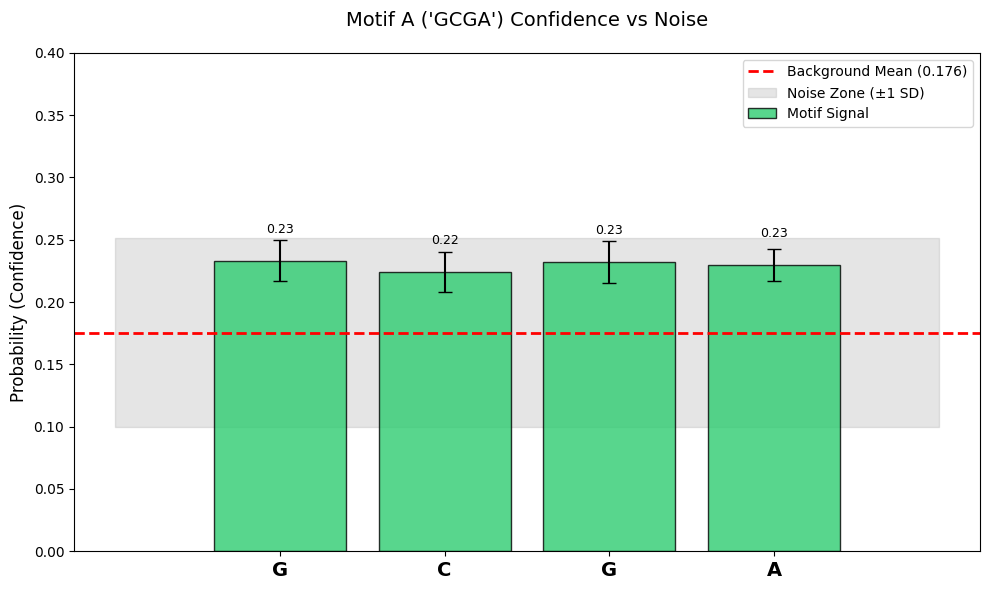

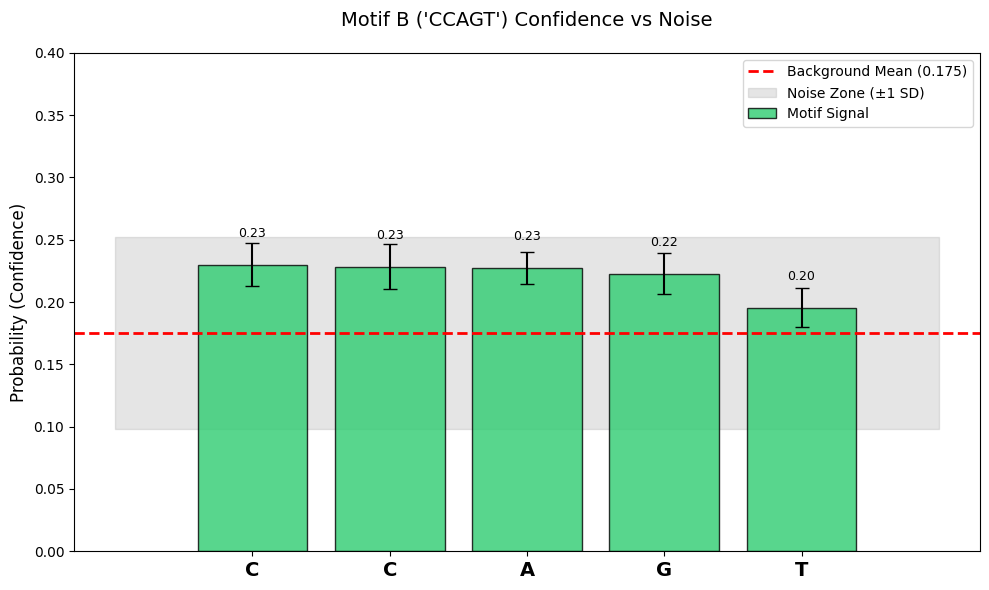

In [14]:
def plot_significance_with_noise_floor(df_stats, title="Significance Test"):
    bg_row = df_stats[df_stats['Position'] == "Background (Global)"].iloc[0]
    bg_mean = bg_row['Avg Probability']
    bg_std = bg_row['Std Dev']

    motif_df = df_stats[df_stats['Position'] != "Background (Global)"].copy()

    fig, ax = plt.subplots(figsize=(10, 6))
    x_positions = range(len(motif_df))
    nucleotides = motif_df['Nucleotide'].tolist()
    probs = motif_df['Avg Probability'].values
    stds = motif_df['Std Dev'].values

    # Noise Floor
    ax.axhline(y=bg_mean, color='red', linestyle='--', linewidth=2, label=f"Background Mean ({bg_mean:.3f})")
    ax.fill_between([-1, len(motif_df)], bg_mean - bg_std, bg_mean + bg_std, color='grey', alpha=0.2,
                    label="Noise Zone (±1 SD)")

    # Bars
    bar_colors = ['#2ecc71' if (p - s) > bg_mean else '#3498db' for p, s in zip(probs, stds)]

    bars = ax.bar(
        x_positions, probs, yerr=stds, capsize=5,
        color=bar_colors, alpha=0.8, edgecolor='black', label='Motif Signal'
    )

    ax.set_title(title, fontsize=14, pad=20)
    ax.set_ylabel("Probability (Confidence)", fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(nucleotides, fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(probs.max() + 0.15, 0.4))
    ax.legend(loc='upper right')

    for bar, p in zip(bars, probs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.02, f'{p:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


# EXECUTE
plot_significance_with_noise_floor(df_stats_A, title=f"Motif A ('{MOTIF_A}') Confidence vs Noise")
plot_significance_with_noise_floor(df_stats_B, title=f"Motif B ('{MOTIF_B}') Confidence vs Noise")

In [15]:
# Total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,940,809
Trainable parameters: 4,940,809
